# Assignment 10

In [1]:
%pip install cartopy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
plt.rcParams['figure.figsize'] = (12, 6)

import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None, downloader=pooch.HTTPDownloader(verify=False)
)

ERROR 1: PROJ: proj_create_from_database: Open of /opt/sw/anaconda3/2023.09/envs/pangeo23/share/proj failed
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'ldeo.columbia.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
/opt/sw/anaconda3/2023.09/envs/pangeo23/lib/python3.11/site-packages/urllib3/connectionpool.py:1097: InsecureRequestWarning: Unverified HTTPS request is being made to host 'www.ldeo.columbia.edu'. Adding certificate verification is strongly advised. See: https://urllib3.readthedocs.io/en/latest/advanced-usage.html#tls-warnings
  warnings.warn(
SHA256 hash of downloaded file: a876cc7106e7dcb1344fbec5dcd7510e5cd947e62049a8cbc188ad05ffe00345
Use this value as the 'known_hash' argument of 'pooch.retrieve' to ensure that the file hasn't changed if i

## 1.1)

In [3]:
ds = xr.open_dataset(fname)
ds

<xarray.Dataset> Size: 737MB
Dimensions:                      (lon: 360, time: 203, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB ...
    cldtemp_total_daynight_mon   (time, lat, lon) float32 53MB ...
    cldtau_total_day_mon         (time, lat, lon) float32 53MB ...
Attributes:
    title:             CERES EBAF (Energy Balanced and Filled) TOA Fluxes. Mo...
    institution:       NASA/LaRC (Langley Research Center) Hampton, Va
    Conventions:       CF-1.4
    comment:           Data is from East to West and South to North.
    Version:           Edition 4.0; Release Date March 7, 2017
    Fill_Value:        Fill Value is -999.0
    DOI:               10.5067/TERRA+AQUA/CERES/EBAF-TOA_L3B.004.0
    Production_Files:  List of files used in creating the present Master netC...

## 1.2)

In [4]:
max_len = max(len(v) for v in ds.data_vars)
for var in ds.data_vars:
    print(f"{var:<{max_len}} : {ds[var].attrs['long_name']}")

toa_sw_all_mon              : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon              : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon             : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon              : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon              : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon             : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon              : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon              : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon             : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon                   : Incoming Solar Flux, Monthly Means
cldarea_total_daynig

## 2.1)

In [5]:
ds_mean = ds.mean(dim='time')
ds_mean

<xarray.Dataset> Size: 4MB
Dimensions:                      (lon: 360, lat: 180)
Coordinates:
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
Data variables: (12/14)
    toa_sw_all_mon               (lat, lon) float32 259kB 122.3 122.3 ... 104.4
    toa_lw_all_mon               (lat, lon) float32 259kB 141.1 141.1 ... 194.1
    toa_net_all_mon              (lat, lon) float32 259kB -91.29 ... -126.3
    toa_sw_clr_mon               (lat, lon) float32 259kB 119.9 119.9 ... 89.47
    toa_lw_clr_mon               (lat, lon) float32 259kB 140.2 140.2 ... 200.4
    toa_net_clr_mon              (lat, lon) float32 259kB -88.03 ... -117.6
    ...                           ...
    toa_cre_net_mon              (lat, lon) float32 259kB -3.253 ... -8.651
    solar_mon                    (lat, lon) float32 259kB 172.1 172.1 ... 172.3
    cldarea_total_daynight_mon   (lat, lon) float32 259kB 51.52 51.52 ... 78.93
    cldpress_total_daynight_mon  (lat, lon) float32 259kB 486.5 486.5 ... 766.9
    cldtemp_total_daynight_mon   (lat, lon) float32 259kB 225.2 225.2 ... 247.9
    cldtau_total_day_mon         (lat, lon) float32 259kB 4.158 4.158 ... 4.821

## 2.2)

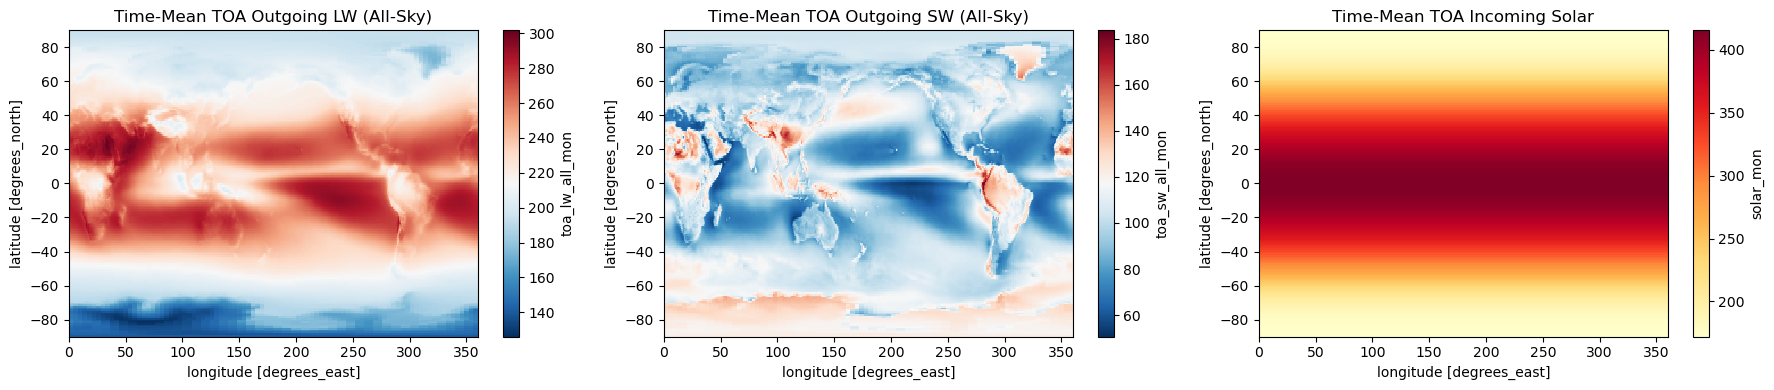

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

ds_mean['toa_lw_all_mon'].plot(ax=axes[0], cmap='RdBu_r')
axes[0].set_title('Time-Mean TOA Outgoing LW (All-Sky)')

ds_mean['toa_sw_all_mon'].plot(ax=axes[1], cmap='RdBu_r')
axes[1].set_title('Time-Mean TOA Outgoing SW (All-Sky)')

ds_mean['solar_mon'].plot(ax=axes[2], cmap='YlOrRd')
axes[2].set_title('Time-Mean TOA Incoming Solar')

plt.tight_layout()
plt.show()

## 2.3)

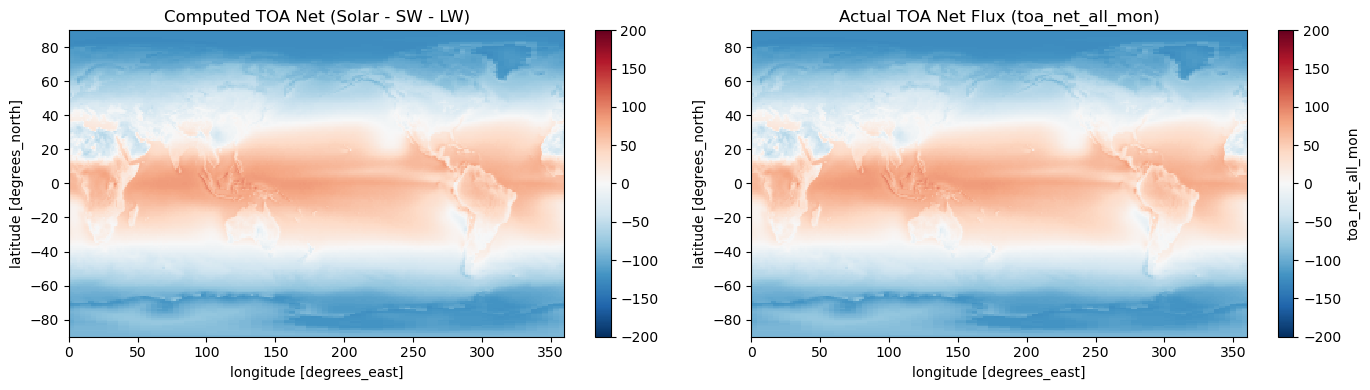

In [7]:
computed_net = ds_mean['solar_mon'] - ds_mean['toa_sw_all_mon'] - ds_mean['toa_lw_all_mon']
actual_net   = ds_mean['toa_net_all_mon']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
computed_net.plot(ax=axes[0], cmap='RdBu_r', vmin=-200, vmax=200)
axes[0].set_title('Computed TOA Net (Solar - SW - LW)')

actual_net.plot(ax=axes[1], cmap='RdBu_r', vmin=-200, vmax=200)
axes[1].set_title('Actual TOA Net Flux (toa_net_all_mon)')

plt.tight_layout()
plt.show()

## 3.1)

In [8]:
unweighted_mean = ds_mean['toa_net_all_mon'].mean()
print(f"Unweighted global mean TOA net radiation: {float(unweighted_mean):.4f} W/m²")

Unweighted global mean TOA net radiation: -28.7290 W/m²


## 3.2)

In [9]:

weights = np.cos(np.deg2rad(ds.lat))
weights.name = 'weights'
weights

<xarray.DataArray 'weights' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361945, 0.06104851, 0.07845908,
       0.09584576, 0.11320324, 0.13052624, 0.14780948, 0.16504757,
       0.18223551, 0.19936794, 0.21643965, 0.23344542, 0.25037998,
       0.26723838, 0.28401536, 0.30070582, 0.3173047 , 0.33380693,
       0.35020736, 0.3665012 , 0.38268346, 0.3987491 , 0.4146933 ,
       0.43051115, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.5075384 , 0.5224986 , 0.5372996 , 0.551937  , 0.56640625,
       0.58070296, 0.59482276, 0.6087614 , 0.62251467, 0.6360782 ,
       0.64944804, 0.66262007, 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.8038569 , 0.8141155 ,
       0.8241262 , 0.83388585, 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.87881714, 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.9426415 , 0.94832367, 0.95371693, 0.95881975, 0.96363044,
       0.96814764, 0.9723699 , 0.976296  , 0.9799247 , 0.9832549 ,
       0.9862856 , 0.9890159 , 0.9914449 , 0.9935719 , 0.9953962 ,
       0.9969173 , 0.9981348 , 0.99904823, 0.99965733, 0.9999619 ,
       0.9999619 , 0.99965733, 0.99904823, 0.9981348 , 0.9969173 ,
       0.9953962 , 0.9935719 , 0.9914449 , 0.9890159 , 0.9862856 ,
       0.9832549 , 0.9799247 , 0.976296  , 0.9723699 , 0.96814764,
       0.96363044, 0.95881975, 0.95371693, 0.94832367, 0.9426415 ,
       0.9366722 , 0.9304176 , 0.9238795 , 0.9170601 , 0.9099613 ,
       0.90258527, 0.89493436, 0.8870108 , 0.87881714, 0.87035567,
       0.8616291 , 0.85264015, 0.8433914 , 0.83388585, 0.8241262 ,
       0.8141155 , 0.8038569 , 0.7933533 , 0.78260815, 0.77162457,
       0.76040596, 0.7489557 , 0.7372773 , 0.72537434, 0.71325046,
       0.70090926, 0.68835455, 0.67559016, 0.66262007, 0.64944804,
       0.6360782 , 0.62251467, 0.6087614 , 0.59482276, 0.58070296,
       0.56640625, 0.551937  , 0.5372996 , 0.5224986 , 0.5075384 ,
       0.49242356, 0.47715878, 0.4617486 , 0.44619778, 0.43051115,
       0.4146933 , 0.3987491 , 0.38268346, 0.3665012 , 0.35020736,
       0.33380693, 0.3173047 , 0.30070582, 0.28401536, 0.26723838,
       0.25037998, 0.23344542, 0.21643965, 0.19936794, 0.18223551,
       0.16504757, 0.14780948, 0.13052624, 0.11320324, 0.09584576,
       0.07845908, 0.06104851, 0.04361945, 0.02617699, 0.00872656],
      dtype=float32)
Coordinates:
  * lat      (lat) float32 720B -89.5 -88.5 -87.5 -86.5 ... 86.5 87.5 88.5 89.5
Attributes:
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north
    valid_range:    [-90.  90.]

## 3.3)

In [10]:
toa_net_mean = ds_mean['toa_net_all_mon']
weighted_mean = toa_net_mean.weighted(weights).mean(('lat', 'lon'))
print(f"Weighted global mean TOA net radiation: {float(weighted_mean):.4f} W/m²")

Weighted global mean TOA net radiation: 0.8781 W/m²


## 3.4)

In [11]:
solar_weighted = ds_mean['solar_mon'].weighted(weights).mean(('lat', 'lon'))
lw_weighted    = ds_mean['toa_lw_all_mon'].weighted(weights).mean(('lat', 'lon'))
sw_weighted    = ds_mean['toa_sw_all_mon'].weighted(weights).mean(('lat', 'lon'))

print(f"TOA Incoming Solar:        {float(solar_weighted):.1f} W/m²  (NASA: ~340 W/m²)")
print(f"TOA Outgoing Longwave:     {float(lw_weighted):.1f} W/m²  (NASA: ~239 W/m²)")
print(f"TOA Outgoing Shortwave:    {float(sw_weighted):.1f} W/m²  (NASA: ~100 W/m²)")


TOA Incoming Solar:        340.3 W/m²  (NASA: ~340 W/m²)
TOA Outgoing Longwave:     240.3 W/m²  (NASA: ~239 W/m²)
TOA Outgoing Shortwave:    99.1 W/m²  (NASA: ~100 W/m²)


## 4.1)

In [12]:
R = 6_371_000  
# earth radius in m

dlat = np.deg2rad(1.0)
dlon = np.deg2rad(1.0)

area = R**2 * np.cos(np.deg2rad(ds_mean.lat)) * dlat * dlon * xr.ones_like(ds_mean['toa_net_all_mon'])
area.name = 'pixel_area'
area.attrs['units'] = 'm²'

total_area = float(area.sum())
true_area  = 4 * np.pi * R**2
print(f"Sum of pixel areas: {total_area:.4e} m²")
print(f"True Earth surface: {true_area:.4e} m²")
print(f"Ratio: {total_area / true_area:.6f}")

Sum of pixel areas: 5.1007e+14 m²
True Earth surface: 5.1006e+14 m²
Ratio: 1.000013


## 4.2)

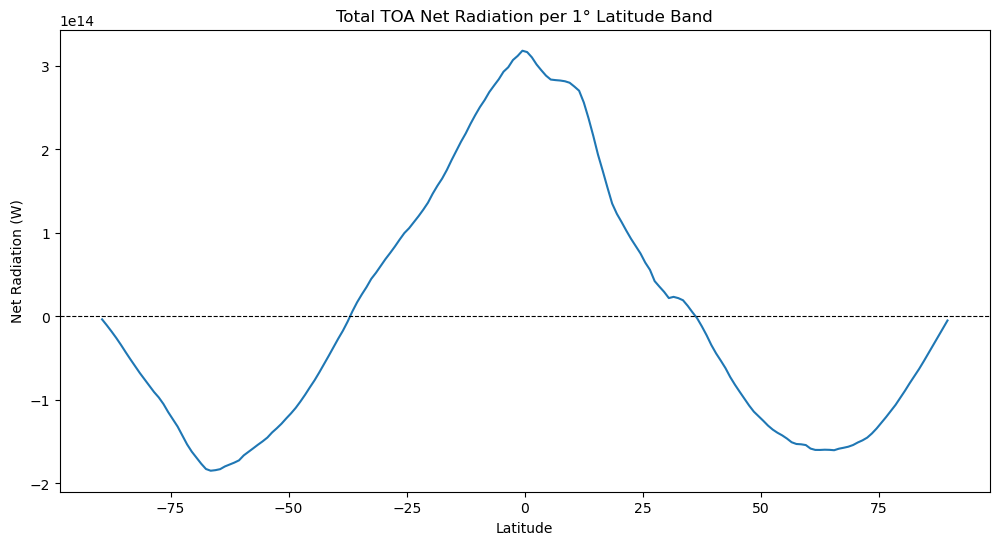

In [13]:
net_flux = ds_mean['toa_net_all_mon']
total_rad_per_lat = (net_flux * area).sum(dim='lon')

total_rad_per_lat.plot()
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')
plt.title('Total TOA Net Radiation per 1° Latitude Band')
plt.xlabel('Latitude')
plt.ylabel('Net Radiation (W)')
plt.show()

## 4.3)

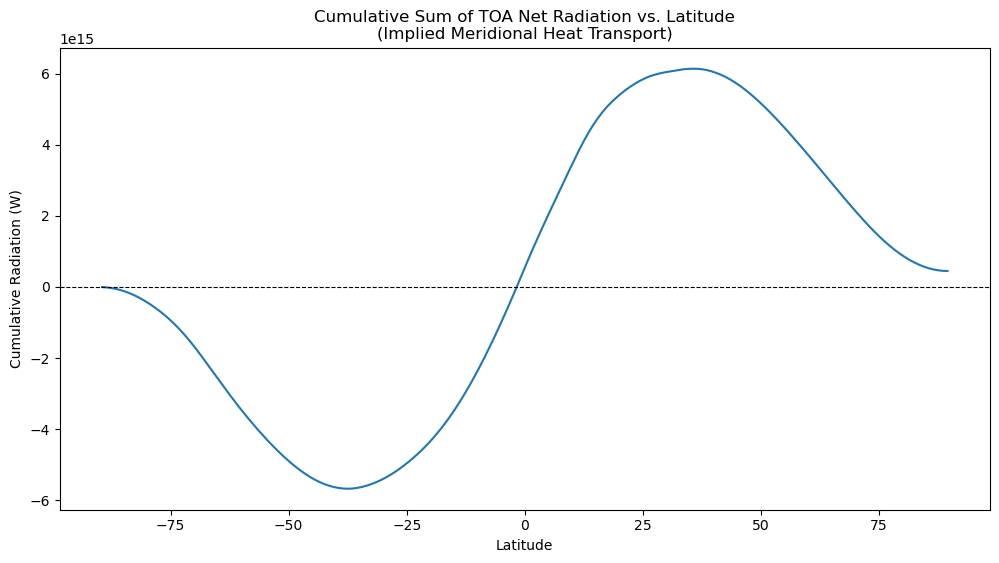

In [14]:
cum_sum = total_rad_per_lat.cumsum(dim='lat')

cum_sum.plot()
plt.axhline(0, color='k', linewidth=0.8, linestyle='--')
plt.title('Cumulative Sum of TOA Net Radiation vs. Latitude\n(Implied Meridional Heat Transport)')
plt.xlabel('Latitude')
plt.ylabel('Cumulative Radiation (W)')
plt.show()

## 5.1)

## 5.2)

In [15]:
import sys
!{sys.executable} -m pip install h5netcdf

Defaulting to user installation because normal site-packages is not writeable


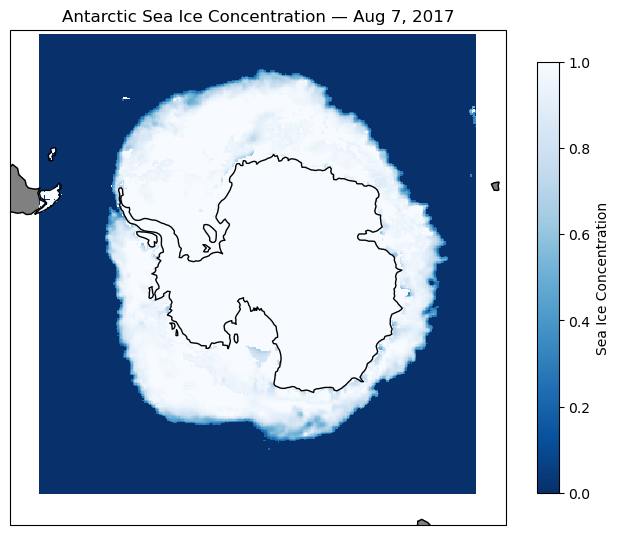

In [17]:
import pooch
import warnings
warnings.filterwarnings('ignore')
url_ice = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname_ice = pooch.retrieve(url_ice,
    known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname_ice, engine='h5netcdf',
                         drop_variables='melt_onset_day_seaice_conc_cdr')

proj_ice = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': proj_ice})
ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
ax.add_feature(cfeature.LAND, color='gray')
ax.add_feature(cfeature.COASTLINE)

ice_conc = ds_ice['seaice_conc_cdr'].isel(time=0)

pcm = ax.pcolormesh(ds_ice.longitude, ds_ice.latitude, ice_conc,
                    transform=ccrs.PlateCarree(),
                    cmap='Blues_r', vmin=0, vmax=1)
plt.colorbar(pcm, ax=ax, label='Sea Ice Concentration', shrink=0.7)
ax.set_title('Antarctic Sea Ice Concentration — Aug 7, 2017')
plt.show()

## 5.3)

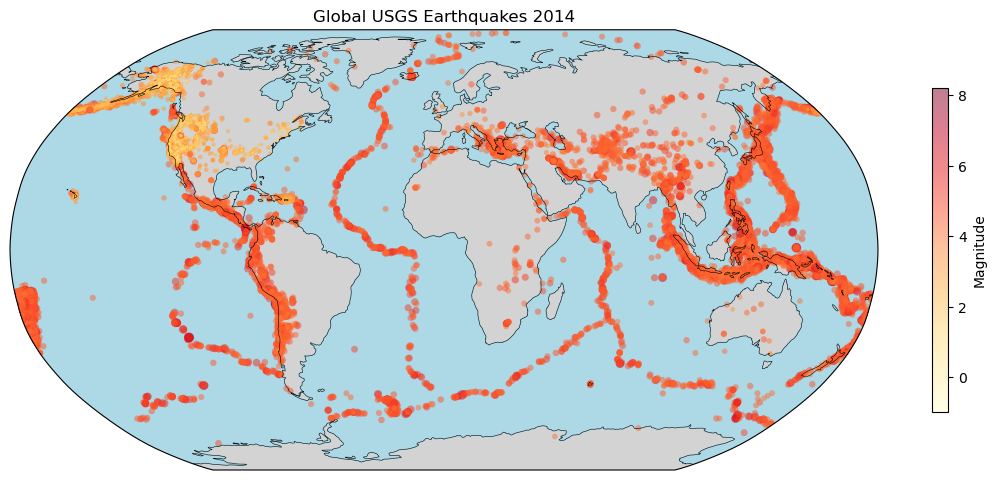

In [18]:
eq_url = 'http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv'
df_eq = pd.read_csv(eq_url)

proj_eq = ccrs.Robinson()
fig, ax = plt.subplots(figsize=(14, 7), subplot_kw={'projection': proj_eq})
ax.set_global()
ax.add_feature(cfeature.LAND,       color='lightgray')
ax.add_feature(cfeature.OCEAN,      color='lightblue')
ax.add_feature(cfeature.COASTLINE,  linewidth=0.4)

sc = ax.scatter(df_eq['longitude'], df_eq['latitude'],
                c=df_eq['mag'],
                s=df_eq['mag']**2,         # size scales with magnitude
                cmap='YlOrRd',
                transform=ccrs.PlateCarree(),
                alpha=0.5, linewidths=0)
plt.colorbar(sc, ax=ax, label='Magnitude', shrink=0.6)
ax.set_title('Global USGS Earthquakes 2014')
plt.show()